In [9]:
# 필수 패키지 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

# SMOTE와 Pipeline (Data Leakage 방지용)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## SVM

### Cell 1: 데이터 로드 및 Feature Engineering

In [3]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)

# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# 3. 파생 변수 생성 (Power = Current * Speed 등)
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]
for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']

df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 4. 입력 피처(X) 설정
input_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
X = df_clean[input_cols]

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개")

데이터 크기: (7355, 31)
피처 개수: 26개


### Cell 2: 타겟 변수 라벨링

In [4]:
# 통합 이진 타겟(System_Failure) 생성: Protective Stop 또는 Grip Lost 발생 시 1
df_clean['Robot_ProtectiveStop'] = df_clean['Robot_ProtectiveStop'].astype(bool).astype(int)
df_clean['grip_lost'] = df_clean['grip_lost'].astype(bool).astype(int)

y = ((df_clean['Robot_ProtectiveStop'] == 1) | (df_clean['grip_lost'] == 1)).astype(int)

print("분류된 타겟(y)의 클래스별 데이터 개수:")
print(y.value_counts().sort_index())
# 0: Normal(정상), 1: Failure(고장)

분류된 타겟(y)의 클래스별 데이터 개수:
0    6837
1     518
Name: count, dtype: int64


### Cell 3: 데이터 분할 및 스케일링

In [5]:
# 1. Train / Test Split (클래스 비율을 유지하기 위해 stratify=y 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. 데이터 스케일링 (로지스틱 회귀 등 거리 기반 모델은 변수 스케일에 민감함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"학습 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

학습 데이터 크기: (5884, 26)
테스트 데이터 크기: (1471, 26)


### Cell 4: Support Vector Machine 학습 및 하이퍼파라미터 튜닝

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Imblearn Pipeline 구축
# probability=True: ROC-AUC 계산 및 확률 출력을 위해 필요 (단, 학습 시간이 조금 늘어남)
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(random_state=42, probability=True))
])

# 파라미터 그리드 (비선형 rbf 커널과 선형 linear 커널 비교)
param_grid = {
    'svc__C': [0.1, 1, 10],                     # 규제 강도 (오차 허용 범위)
    'svc__gamma': ['scale', 'auto', 0.1],       # 결정 경계의 곡률 (rbf 커널용)
    'svc__kernel': ['rbf', 'linear']            # 커널 종류
}

print("--- SVM 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 (시간이 다소 소요됩니다) ---")
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search.best_params_.items():
    print(f"  • {param.replace('svc__', '')}: {value}")
print("")
print(f"최고 교차 검증 F1-Macro 점수: {grid_search.best_score_:.4f}")

--- SVM 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 (시간이 다소 소요됩니다) ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • C: 10
  • gamma: scale
  • kernel: rbf

최고 교차 검증 F1-Macro 점수: 0.6808


### Cell 5: 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [10]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top_models = cv_results_df.sort_values('rank_test_score').head(10)

# 비교 결과를 담을 리스트
comparison_data = []
print("--- [모델 비교] 상위 10개 SVM 성능 종합 ---")

# 2. 상위 모델들을 하나씩 돌려가며 Train/Test 평가 진행
for index, row in top_models.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_f1 = row['mean_test_score']
    
    # 해당 파라미터로 재학습
    model = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('svc', SVC(
            C=params.get('svc__C', 1.0),
            gamma=params.get('svc__gamma', 'scale'),
            kernel=params.get('svc__kernel', 'rbf'),
            random_state=42,
            probability=True
        ))
    ])
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # ROC-AUC를 계산하기 위한 확률(Probability) 예측
    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

    # 평가지표 계산
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # ROC-AUC 점수 계산
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    # 파라미터 설정을 간소화된 문자열로 변환
    c_val = params.get('svc__C', '-')
    gam_val = params.get('svc__gamma', '-')
    ker_val = params.get('svc__kernel', '-')
    param_short = f"C={c_val}, G={gam_val}, K={ker_val}"
    
    # 결과 저장
    comparison_data.append({
        '순위': rank,
        'CV F1': round(cv_f1, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        '과적합 Gap': round(train_f1 - test_f1, 4), 
        'Train Acc': round(train_acc, 6),
        'Test Acc': round(test_acc, 6),
        'Test ROC-AUC': round(test_roc_auc, 6),
        '파라미터 설정': param_short
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

--- [모델 비교] 상위 10개 SVM 성능 종합 ---


,순위,CV F1,Train F1,Test F1,과적합 Gap,Train Acc,Test Acc,Test ROC-AUC,파라미터 설정
0,1,0.6808,0.7664,0.7258,0.0406,0.911285,0.900748,0.860774,"C=10, G=scale, K=rbf"
1,2,0.6804,0.7825,0.7112,0.0713,0.917573,0.889871,0.868859,"C=10, G=0.1, K=rbf"
2,3,0.6776,0.7495,0.7285,0.0210,0.901598,0.899388,0.860883,"C=1, G=0.1, K=rbf"
3,4,0.6759,0.7526,0.7258,0.0268,0.904657,0.900748,0.863809,"C=10, G=auto, K=rbf"
4,5,0.6619,0.7088,0.7063,0.0025,0.883923,0.889871,0.863900,"C=1, G=scale, K=rbf"
5,6,0.6599,0.7004,0.7079,-0.0076,0.878824,0.889871,0.864498,"C=1, G=auto, K=rbf"
6,7,0.6532,0.6934,0.6929,0.0006,0.877804,0.887831,0.856754,"C=0.1, G=0.1, K=rbf"
7,8,0.6186,0.6443,0.6676,-0.0233,0.840075,0.859959,0.847497,"C=0.1, G=scale, K=rbf"
8,9,0.6163,0.6390,0.6676,-0.0287,0.835656,0.858600,0.847645,"C=0.1, G=auto, K=rbf"
9,10,0.4934,0.5159,0.5341,-0.0181,0.679470,0.690007,0.784783,"C=10, G=scale, K=linear"


### Cell 6: 특정 순위 모델 최종 평가지표 상세 분석

In [13]:
print("\n" + "="*50)
target_rank = 3
print(f"--- [상세 분석] {target_rank}위 모델 최종 평가지표 ---")
print("="*50)

selected_row = top_models[top_models['rank_test_score'] == target_rank].iloc[0]
selected_params = selected_row['params']

print(f"\n[선택된 {target_rank}위 모델의 하이퍼파라미터]")
for param, value in selected_params.items():
    print(f"  • {param.replace('svc__', '')}: {value}")

# 재학습 모델 정의 (probability=True 추가)
selected_model = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(
        C=selected_params.get('svc__C', 1.0),
        gamma=selected_params.get('svc__gamma', 'scale'),
        kernel=selected_params.get('svc__kernel', 'rbf'),
        random_state=42, class_weight='balanced',
        probability=True
    ))
])
selected_model.fit(X_train_scaled, y_train)

# 예측 클래스 및 확률 계산
y_train_pred_selected = selected_model.predict(X_train_scaled)
y_train_prob_selected = selected_model.predict_proba(X_train_scaled)[:, 1]

y_test_pred_selected = selected_model.predict(X_test_scaled)
y_test_prob_selected = selected_model.predict_proba(X_test_scaled)[:, 1]

# 평가지표 출력 함수 (y_prob 인자 추가)
def print_metrics(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_prob)  # ROC-AUC 계산
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"Accuracy (정확도) : {acc:.4f}")
    print(f"F1-Macro Score    : {f1_macro:.6f}")
    print(f"ROC-AUC Score     : {roc_auc:.6f}")  # ROC-AUC 출력 추가
    print(f"\n[{dataset_name} 상세 분류 리포트]")
    print(classification_report(y_true, y_pred, target_names=['0 (Normal)', '1 (Failure)']))

# 함수 호출 시 확률값도 함께 전달
print_metrics(y_train, y_train_pred_selected, y_train_prob_selected, "Train")
print_metrics(y_test, y_test_pred_selected, y_test_prob_selected, "Test")

y_test_pred = y_test_pred_selected


--- [상세 분석] 3위 모델 최종 평가지표 ---

[선택된 3위 모델의 하이퍼파라미터]
  • C: 1
  • gamma: 0.1
  • kernel: rbf

[Train 데이터 평가]
Accuracy (정확도) : 0.9016
F1-Macro Score    : 0.749483
ROC-AUC Score     : 0.932674

[Train 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.99      0.90      0.94      5470
 1 (Failure)       0.41      0.87      0.55       414

    accuracy                           0.90      5884
   macro avg       0.70      0.89      0.75      5884
weighted avg       0.95      0.90      0.92      5884


[Test 데이터 평가]
Accuracy (정확도) : 0.8994
F1-Macro Score    : 0.728527
ROC-AUC Score     : 0.860883

[Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.98      0.91      0.94      1367
 1 (Failure)       0.39      0.75      0.51       104

    accuracy                           0.90      1471
   macro avg       0.68      0.83      0.73      1471
weighted avg       0.94      0.90      0.91      1471



### Cell 7: 오차 행렬(Confusion Matrix) 시각화

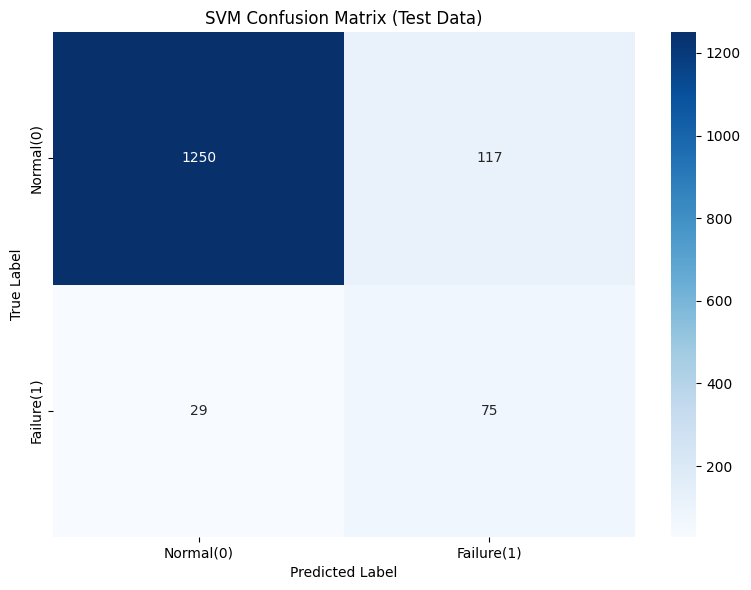

In [12]:
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Normal(0)', 'Failure(1)'], yticklabels=['Normal(0)', 'Failure(1)'])
plt.title(f'SVM Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Cell 9: SMOTE vs SMOTE+Undersampling 성능 비교 및 시각화 (ROC Curve & 2D 결정 경계)

--- SVM: SMOTE vs SMOTE+ENN 비교 분석 시작 ---

[SMOTE + ENN 모델 Test 상세 분류 리포트]
              precision    recall  f1-score   support

  0 (Normal)       0.97      0.91      0.94      1367
 1 (Failure)       0.35      0.63      0.45       104

    accuracy                           0.89      1471
   macro avg       0.66      0.77      0.69      1471
weighted avg       0.93      0.89      0.90      1471



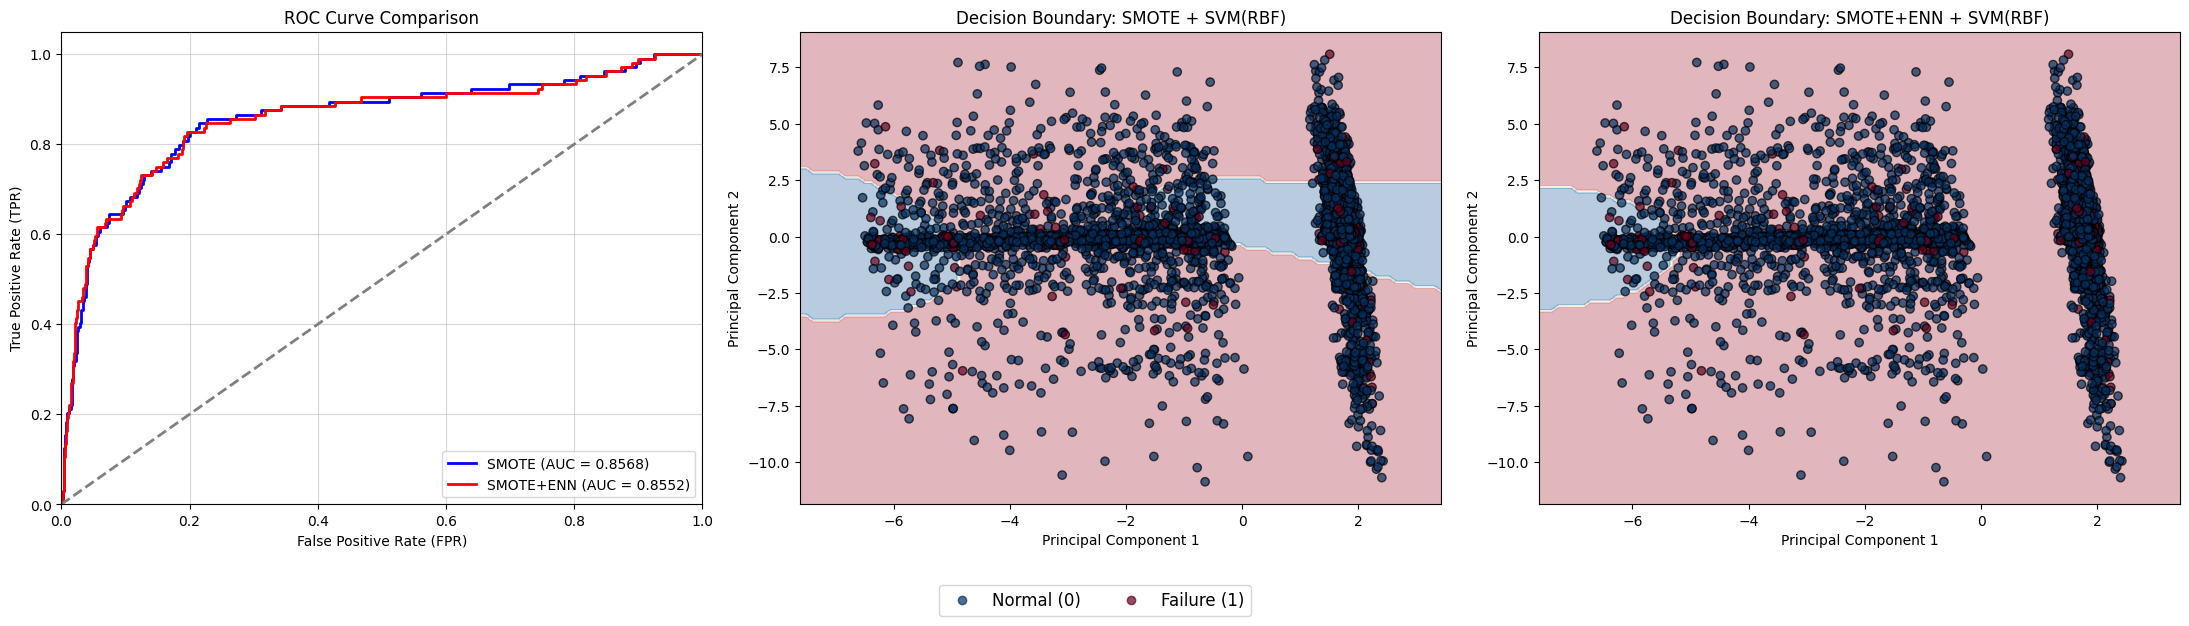

In [14]:
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

print("--- SVM: SMOTE vs SMOTE+ENN 비교 분석 시작 ---")

# ==========================================
# 1. 원본 26차원 데이터로 학습 및 성능 평가
# ==========================================
best_params = {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

# (1) SMOTE 파이프라인
model_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(**best_params, random_state=42, probability=True))
])
model_smote.fit(X_train_scaled, y_train)
y_test_pred_smote = model_smote.predict(X_test_scaled)
y_test_prob_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

# (2) SMOTE + ENN 파이프라인
model_smote_enn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('enn', EditedNearestNeighbours(n_neighbors=3, kind_sel='all')),
    ('svc', SVC(**best_params, random_state=42, probability=True))
])
model_smote_enn.fit(X_train_scaled, y_train)
y_test_pred_enn = model_smote_enn.predict(X_test_scaled)
y_test_prob_enn = model_smote_enn.predict_proba(X_test_scaled)[:, 1]

print("\n[SMOTE + ENN 모델 Test 상세 분류 리포트]")
print(classification_report(y_test, y_test_pred_enn, target_names=['0 (Normal)', '1 (Failure)']))


# ==========================================
# 2. ROC Curve 시각화 (모델 성능 비교)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_test_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

fpr_enn, tpr_enn, _ = roc_curve(y_test, y_test_prob_enn)
roc_auc_enn = auc(fpr_enn, tpr_enn)

axes[0].plot(fpr_smote, tpr_smote, color='blue', lw=2, label=f'SMOTE (AUC = {roc_auc_smote:.4f})')
axes[0].plot(fpr_enn, tpr_enn, color='red', lw=2, label=f'SMOTE+ENN (AUC = {roc_auc_enn:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.5)


# ==========================================
# 3. PCA 2D 결정 경계 시각화 (비선형 커널의 힘 확인)
# ==========================================
# 시각화를 위해 PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2D 축소 데이터로 모델 재학습
model_smote.fit(X_train_pca, y_train)
model_smote_enn.fit(X_train_pca, y_train)

scatter_kwargs = {'edgecolors': 'k', 'alpha': 0.7}

# SMOTE 시각화
DecisionBoundaryDisplay.from_estimator(
    model_smote, X_train_pca, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.3, ax=axes[1]
)
scatter1 = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, **scatter_kwargs)
axes[1].set_title('Decision Boundary: SMOTE + SVM(RBF)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# SMOTE + ENN 시각화
DecisionBoundaryDisplay.from_estimator(
    model_smote_enn, X_train_pca, response_method="predict",
    cmap=plt.cm.RdBu, alpha=0.3, ax=axes[2]
)
axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.RdBu_r, **scatter_kwargs)
axes[2].set_title('Decision Boundary: SMOTE+ENN + SVM(RBF)')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')

handles, labels = scatter1.legend_elements()
fig.legend(handles, ['Normal (0)', 'Failure (1)'], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()